In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

LAGS = [1, 2, 52]
ROLL_WINDOWS = [4, 8]
RANDOM_STATE = 42

TEST_WEEKS = 104
SEASONALITY = 52

In [2]:
# ----------------------------------------------------------------------
# Reuse the Part 3 helpers so diagnostics/metrics are identical
# ----------------------------------------------------------------------

def evaluate(name, y_true, y_pred, y_train, seasonality=SEASONALITY):
    y_pred = y_pred.reindex(y_true.index)
    err = y_pred.to_numpy() - y_true.to_numpy()
    yt = y_train.to_numpy()
    scale = np.mean(np.abs(yt[seasonality:] - yt[:-seasonality]))
    return {
        "model": name,
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MASE": float(np.mean(np.abs(err)) / scale),
        "Bias": float(np.mean(err)),
    }

def coverage(ci, y_true):
    inside = (y_true.to_numpy() >= ci["lower"].to_numpy()) & \
             (y_true.to_numpy() <= ci["upper"].to_numpy())
    return float(inside.mean())

In [3]:
# ----------------------------------------------------------------------
# 1. Feature engineering (leakage-safe)
# ----------------------------------------------------------------------

def make_calendar_features(index: pd.DatetimeIndex) -> pd.DataFrame:
    """Cyclic week-of-year + month. All known for any week, past or future."""
    idx = pd.DatetimeIndex(index)
    week = idx.isocalendar().week.astype(int).to_numpy()
    return pd.DataFrame(
        {
            "wk_sin": np.sin(2 * np.pi * week / 52.0),
            "wk_cos": np.cos(2 * np.pi * week / 52.0),
            "month": idx.month.to_numpy(),
        },
        index=index,
    )


def make_supervised_table(feature_df: pd.DataFrame,
                          lags=LAGS, roll_windows=ROLL_WINDOWS) -> pd.DataFrame:
    """
    Build the modelling table. `feature_df` must contain 'load_gw' plus the
    temperature columns. Lag/rolling features use shift() so no future target
    leaks in. Rolling stats are computed on shift(1) so week t sees only
    weeks <= t-1.
    """
    df = feature_df.copy()
    cal = make_calendar_features(df.index)
    df = df.join(cal)

    for L in lags:
        df[f"lag_{L}"] = df["load_gw"].shift(L)
    past = df["load_gw"].shift(1)
    for W in roll_windows:
        df[f"roll_mean_{W}"] = past.rolling(W).mean()
        df[f"roll_std_{W}"] = past.rolling(W).std()

    return df.dropna()


def feature_columns(table: pd.DataFrame, temp_cols) -> list[str]:
    cal_cols = ["wk_sin", "wk_cos", "month"]
    lag_cols = [c for c in table.columns if c.startswith(("lag_", "roll_"))]
    return cal_cols + list(temp_cols) + lag_cols

In [4]:
# ----------------------------------------------------------------------
# 2. Recursive multi-step forecast
# ----------------------------------------------------------------------

def _feature_row(history_load: pd.Series, exog_row: dict, cal_row: dict,
                 lags, roll_windows) -> dict:
    """Feature vector for one future week, from known-or-predicted past load."""
    feat = {}
    for L in lags:
        feat[f"lag_{L}"] = history_load.iloc[-L]
    for W in roll_windows:
        window = history_load.iloc[-W:]
        feat[f"roll_mean_{W}"] = window.mean()
        feat[f"roll_std_{W}"] = window.std()
    feat.update(exog_row)
    feat.update(cal_row)
    return feat


def recursive_forecast(models: dict, train_load: pd.Series,
                       future_df: pd.DataFrame, temp_cols, feat_cols,
                       lags=LAGS, roll_windows=ROLL_WINDOWS) -> pd.DataFrame:
    """
    Forecast every week in `future_df` recursively.
    `models` maps name -> fitted regressor; the 'point' model drives the
    recursion (its prediction is fed back as the next lag), while any quantile
    models are evaluated on the same feature row to form a band.
    """
    history = train_load.copy()
    cal = make_calendar_features(future_df.index)
    out = {name: [] for name in models}

    for ts in future_df.index:
        exog_row = {c: future_df.at[ts, c] for c in temp_cols}
        cal_row = cal.loc[ts].to_dict()
        row = _feature_row(history, exog_row, cal_row, lags, roll_windows)
        x = pd.DataFrame([row])[feat_cols]

        preds = {name: float(m.predict(x)[0]) for name, m in models.items()}
        for name, val in preds.items():
            out[name].append(val)

        # feed the POINT prediction back in as the newest actual
        history = pd.concat([history, pd.Series([preds["point"]], index=[ts])])

    return pd.DataFrame(out, index=future_df.index)

In [5]:
# ----------------------------------------------------------------------
# 3. Fit + forecast orchestration
# ----------------------------------------------------------------------

def fit_models(X_train, y_train, quantiles=(0.05, 0.95)):
    """Point GBM + RF, plus two quantile GBMs for a prediction band."""
    point = GradientBoostingRegressor(
        n_estimators=400, max_depth=3, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE,
    ).fit(X_train, y_train)

    rf = RandomForestRegressor(
        n_estimators=400, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1,
    ).fit(X_train, y_train)

    lo = GradientBoostingRegressor(
        loss="quantile", alpha=quantiles[0], n_estimators=400, max_depth=3,
        learning_rate=0.05, subsample=0.8, random_state=RANDOM_STATE,
    ).fit(X_train, y_train)
    hi = GradientBoostingRegressor(
        loss="quantile", alpha=quantiles[1], n_estimators=400, max_depth=3,
        learning_rate=0.05, subsample=0.8, random_state=RANDOM_STATE,
    ).fit(X_train, y_train)

    return {"point": point, "lower": lo, "upper": hi}, rf


def plot_forecast(train, test, mean, ci, path=None, title="Feature model forecast"):
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(train.index, train, color="tab:gray", lw=1, label="Train")
    ax.plot(test.index, test, color="black", lw=2, label="Test (actual)")
    ax.plot(mean.index, mean, color="tab:blue", lw=1.8, label="Feature model")
    if ci is not None:
        ax.fill_between(ci.index, ci["lower"], ci["upper"],
                        color="tab:blue", alpha=0.15, label="90% interval")
    ax.axvline(test.index[0], color="k", lw=0.8, alpha=0.4)
    ax.set_title(title + " -- weekly German load, 2-year horizon")
    ax.set_ylabel("Load (GW)")
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig


def plot_importance(model, feat_cols, path=None, top=15):
    imp = pd.Series(model.feature_importances_, index=feat_cols).sort_values()
    fig, ax = plt.subplots(figsize=(8, 6))
    imp.tail(top).plot.barh(ax=ax, color="tab:blue")
    ax.set_title("Gradient boosting feature importance")
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig, imp


def run_part5(feature_df: pd.DataFrame, test_weeks: int = TEST_WEEKS,
              temp_cols=("temp_mean", "heating_degree", "cooling_degree"),
              comparison_rmse: dict | None = None, save_dir: str | None = None):
    import os
    temp_cols = list(temp_cols)

    table = make_supervised_table(feature_df)
    feat_cols = feature_columns(table, temp_cols)

    y = table["load_gw"]
    X = table[feat_cols]

    # chronological split on the SUPERVISED table
    y_train, y_test = y.iloc[:-test_weeks], y.iloc[-test_weeks:]
    X_train = X.iloc[:-test_weeks]

    print(f"Supervised table: {len(table)} rows, {len(feat_cols)} features")
    print(f"Train {len(y_train)}, Test {len(y_test)}\nFeatures: {feat_cols}\n")

    models, rf = fit_models(X_train, y_train)

    # recursive multi-step forecast over the test window
    future_df = feature_df.loc[y_test.index]
    train_load = feature_df["load_gw"].loc[:y_train.index[-1]]
    preds = recursive_forecast(models, train_load, future_df, temp_cols, feat_cols)

    mean = preds["point"]
    ci = preds[["lower", "upper"]].copy()

    gbm_metrics = evaluate("feature_model_GBM", y_test, mean, y_train)
    # RF (also recursive, driven by its own predictions)
    rf_preds = recursive_forecast({"point": rf}, train_load, future_df,
                                  temp_cols, feat_cols)["point"]
    rf_metrics = evaluate("feature_model_RF", y_test, rf_preds, y_train)

    print("Forecast accuracy (recursive, conditional on observed temperature):")
    print(pd.DataFrame([gbm_metrics, rf_metrics]).round(3).to_string(index=False))
    print(f"GBM 90% interval coverage: {coverage(ci, y_test):.1%}")

    # comparison
    comp = [{"model": gbm_metrics["model"], "RMSE": gbm_metrics["RMSE"]},
            {"model": rf_metrics["model"], "RMSE": rf_metrics["RMSE"]}]
    if comparison_rmse:
        comp += [{"model": k, "RMSE": v} for k, v in comparison_rmse.items()]
    comp_df = pd.DataFrame(comp).sort_values("RMSE")
    print("\nRMSE comparison:")
    print(comp_df.round(3).to_string(index=False))

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        pd.DataFrame({"actual": y_test, "gbm": mean, "rf": rf_preds,
                      "lower": ci["lower"], "upper": ci["upper"]}).to_csv(
            os.path.join(save_dir, "feature_forecast.csv"))
    _, imp = plot_importance(models["point"], feat_cols,
                             os.path.join(save_dir, "feature_importance.png") if save_dir else None)
    print("\nTop feature importances:")
    print(imp.sort_values(ascending=False).head(6).round(3).to_string())
    plot_forecast(y_train, y_test, mean, ci,
                  os.path.join(save_dir, "feature_forecast.png") if save_dir else None)

    return models, gbm_metrics, (mean, ci), imp

Supervised table: 249 rows, 13 features
Train 145, Test 104
Features: ['wk_sin', 'wk_cos', 'month', 'temp_mean', 'heating_degree', 'cooling_degree', 'lag_1', 'lag_2', 'lag_52', 'roll_mean_4', 'roll_std_4', 'roll_mean_8', 'roll_std_8']

Forecast accuracy (recursive, conditional on observed temperature):
            model   MAE  RMSE  MASE  Bias
feature_model_GBM 2.470 3.265 1.792 1.818
 feature_model_RF 2.212 2.970 1.604 1.687
GBM 90% interval coverage: 36.5%

RMSE comparison:
              model  RMSE
   feature_model_RF 2.970
seasonal naive (P2) 3.007
  feature_model_GBM 3.265
  SARIMAX+temp (P4) 3.553
        SARIMA (P3) 3.762

Top feature importances:
lag_52            0.719
lag_1             0.105
wk_cos            0.034
temp_mean         0.027
heating_degree    0.020
roll_std_4        0.018


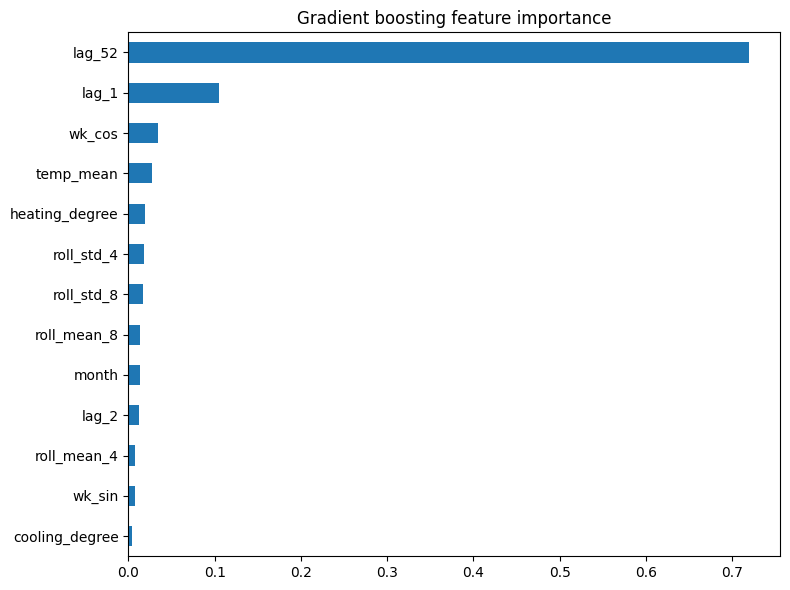

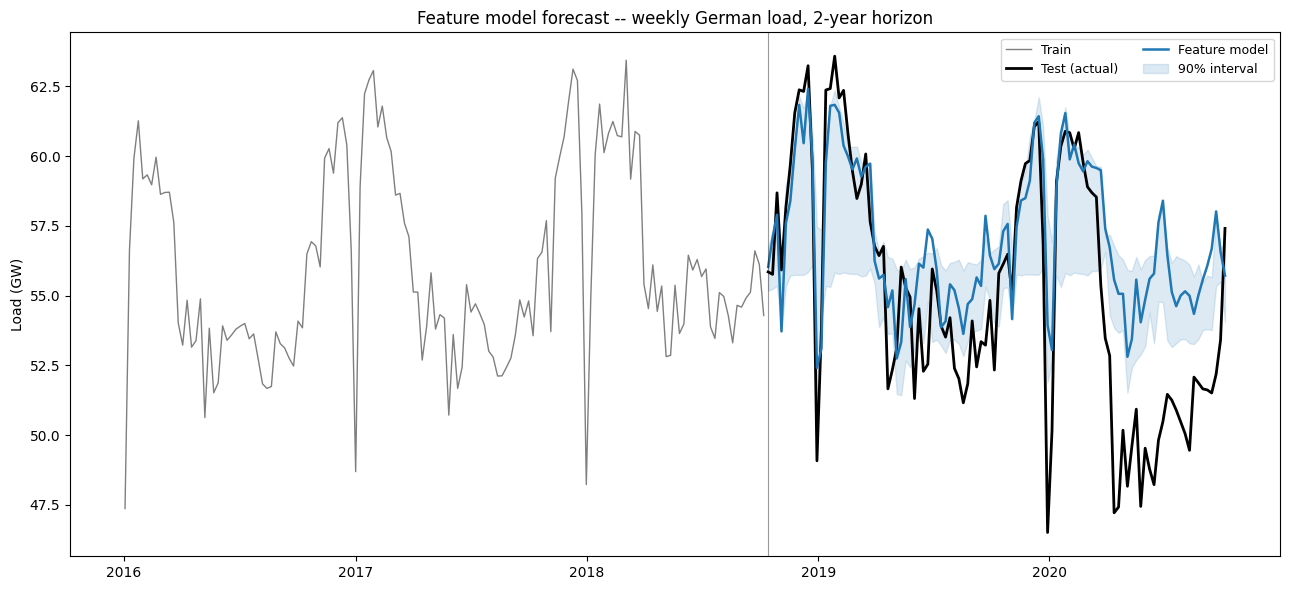

In [6]:
feature_df = pd.read_csv("outputs/04/feature_df.csv", index_col=0, parse_dates=True)

models, gbm_metrics, (mean, ci), imp = run_part5(
    feature_df,
    comparison_rmse={
        "seasonal naive (P2)": 3.007,
        "SARIMA (P3)": 3.762,
        "SARIMAX+temp (P4)": 3.553,
    },
    save_dir="outputs/05",
)